In [1]:
GAMMA = 2.1
N = 1000
BETA = 2.1
K = 20


# working_folder = f'./slides-nets'
# s1h2_working_folder = f'{working_folder}/s1h2-s={seed}'
# er_working_folder = f'{working_folder}/er-s={seed}'
# ba_working_folder = f'{working_folder}/ba-s={seed}'
# conf_working_folder = f'{working_folder}/conf-s={seed}'

# er_file = f'{er_working_folder}/er-n={n}-k={k}-s={seed}'
# ba_file = f'{ba_working_folder}/ba-n={n}-k={k}-s={seed}'
# conf_file = f'{conf_working_folder}/conf-n={n}-k={k}-g={g}-s={seed}'
# s1h2_file = f'{s1h2_working_folder}/s1h2-n={n}-k={k}-g={g}-b={b}-s={seed}'

# er_edges_file = f'{er_file}.edge'
# ba_edges_file = f'{ba_file}.edge'
# conf_edges_file = f'{conf_file}.edge'
# s1h2_edges_file = f'{s1h2_file}.edge'


# er_coords_file = f'{er_file}.inf_coord'
# ba_coords_file = f'{ba_file}.inf_coord'
# conf_coords_file = f'{conf_file}.inf_coord'
# s1h2_coords_file = f'{s1h2_file}.gen_coord'

def get_network_file(model, net_seed, extension):
    """Return the full path to the edge file for a given model and network seed."""
    base = f'generated-nets-2/{model}-s={net_seed}'
    if model == 'er':
        return f'{base}/er-n={N}-k={K}-s={net_seed}.{extension}'
    elif model == 'ba':
        return f'{base}/ba-n={N}-k={K}-s={net_seed}.{extension}'
    elif model == 'conf':
        return f'{base}/conf-n={N}-k={K}-g={GAMMA}-s={net_seed}.{extension}'
    elif model == 's1h2':
        return f'{base}/s1h2-n={N}-k={K}-g={GAMMA}-b={BETA}-s={net_seed}.{extension}'
    else:
        raise ValueError(f'Unknown model: {model}')

def get_edges_file(model, net_seed):
    return get_network_file(model, net_seed, 'edge')

def get_coords_file(model, net_seed):
    return get_network_file(model, net_seed, 'gen_coord' if model == 's1h2' else 'inf_coord')

In [ ]:
's1h2'
'conf'
'ba'
'er'

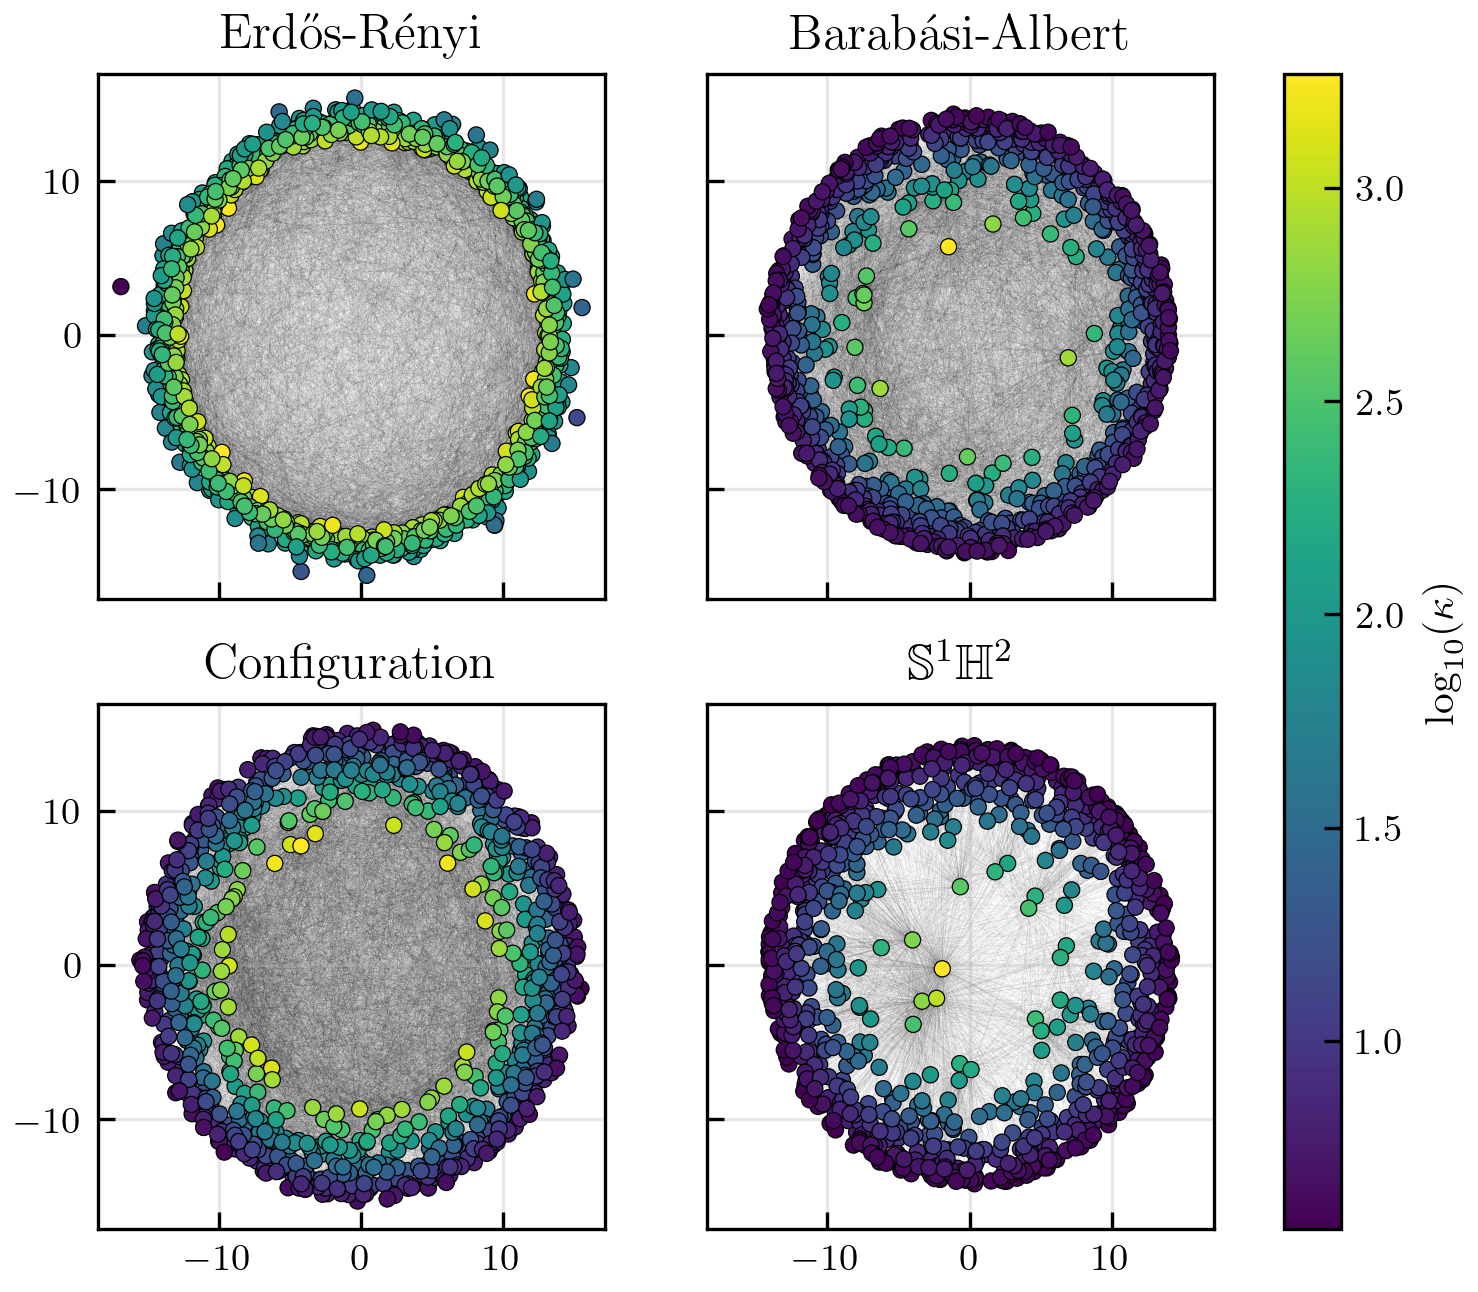

In [3]:
import pipeline.data as data
Gs1h2, dfs1h2, _ = data.read_hyperbolic_data(get_coords_file('s1h2', 12345), get_edges_file('s1h2', 12345), True)
Gconf, dfconf, _ = data.read_hyperbolic_data(get_coords_file('conf', 12345), get_edges_file('conf', 12345))
Gba, dfba, _ = data.read_hyperbolic_data(get_coords_file('ba', 12345)  , get_edges_file('ba', 12345)  )
Ger, dfer, _ = data.read_hyperbolic_data(get_coords_file('er', 12345)  , get_edges_file('er', 12345)  )


import pipeline.figures as figs
import matplotlib.pyplot as plt
import pipeline.init as init
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import numpy as np

init.configure_matplotlib()


fig, axes = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(6, 5), dpi=300)
[ax1, ax2, ax3, ax4] = axes.flat
arr = np.append(np.array([dfba['Inf.Kappa'], dfer['Inf.Kappa'], dfconf['Inf.Kappa']]).flatten(), dfs1h2['Inf.Kappa'])
vmax = np.max(np.log10(arr))
vmin = np.min(np.log10(arr))

figs.mercator_disc_ax(ax1, dfer,  title='Erdős-Rényi', net=Ger, linecolor='#00000020')
figs.mercator_disc_ax(ax2, dfba, title='Barabási-Albert', net=Gba, linecolor='#00000020')
figs.mercator_disc_ax(ax3, dfconf,  title='Configuration', net=Gconf, linecolor='#00000020')
figs.mercator_disc_ax(ax4, dfs1h2,  title=r'$\mathbb{S}^1\mathbb{H}^2$', net=Gs1h2, linecolor='#00000020')

norm = Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap='viridis')
sm.set_array([])

# Añadir la colorbar
cbar = fig.colorbar(sm, ax=[ax1, ax2, ax3, ax4], label=r'$\log_{10}(\kappa)$')
# fig.suptitle('Synthetic complex networks - Mercator embedding\n$N=10^3, \\gamma=2.1, \\langle k \\rangle = 20, \\beta = 2.1$')
# fig.tight_layout()

fig.savefig('slides-figs/mutliple_nets.pdf')
plt.show()

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pipeline.figures as figs
import pipeline.init as init
import pipeline.data as data
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

init.configure_matplotlib()

labels = {
    's1h2': r'$\mathbb{S}^1\mathbb{H}^2$',
    'conf': r'Conf.',
    'ba': r'B--A',
    'er': r'E--R',
}

def crear_grid_con_escalas_compartidas(modelos, seeds, vmin, vmax, output_file='comparativa_con_escalas.pdf'):
    """
    Grid con ejes compartidos pero ocultos.
    """
    n_modelos = len(modelos)
    n_seeds = len(seeds)
    
    fig, axes = plt.subplots(n_modelos, n_seeds, 
                             figsize=(n_seeds * 2.8, n_modelos * 2.8),
                             sharex=True, sharey=True,
                             constrained_layout=True)
    
    if n_modelos == 1:
        axes = axes.reshape(1, -1)
    if n_seeds == 1:
        axes = axes.reshape(-1, 1)
    
    # Primero cargar todos los datos para encontrar límites globales
    datos = {}
    x_min, x_max = float('inf'), float('-inf')
    y_min, y_max = float('inf'), float('-inf')
    
    for model in modelos:
        datos[model] = {}
        for seed in seeds:
            coords_file = get_coords_file(model, seed)
            edges_file = get_edges_file(model, seed)
            G, df, params = data.read_hyperbolic_data(coords_file, edges_file, model == 's1h2')
            datos[model][seed] = (G, df, params)
            
            # Actualizar límites con las coordenadas del disco
            if 'Disc.X' in df.columns:
                x_min = min(x_min, df['Disc.X'].min())
                x_max = max(x_max, df['Disc.X'].max())
                y_min = min(y_min, df['Disc.Y'].min())
                y_max = max(y_max, df['Disc.Y'].max())
    
    # Añadir un poco de margen
    x_padding = (x_max - x_min) * 0.05
    y_padding = (y_max - y_min) * 0.05
    x_limits = (x_min - x_padding, x_max + x_padding)
    y_limits = (y_min - y_padding, y_max + y_padding)
    
    print(f"📊 Límites globales: X={x_limits}, Y={y_limits}")
    
    # Graficar con límites fijos
    for i, model in enumerate(modelos):
        for j, seed in enumerate(seeds):
            print(f'{model}-{seed}')
            ax = axes[i, j]
            G, df, params = datos[model][seed]
            
            # Graficar (esto añade los puntos y aristas)
            figs.mercator_disc_ax(ax, df, net=G, linecolor='#00000020')
            
            # Forzar límites globales
            ax.set_xlim(x_limits)
            ax.set_ylim(y_limits)
            
            # Ocultar ejes pero mantener la escala
            # ax.set_axis_off()
            
            # Asegurar que la relación de aspecto sea igual
            ax.set_aspect('equal')
            
            # Etiqueta del modelo (solo primera columna)
            if j == 0:
                ax.text(-0.12, 0.5, labels[model], transform=ax.transAxes,
                       fontsize=20, fontweight='bold', va='center', ha='right',
                       rotation=90)
    
    # Barra de color global
    sm = plt.cm.ScalarMappable(cmap='viridis', norm=Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    # cbar = fig.colorbar(sm, ax=axes, orientation='horizontal', 
    #                     pad=0.02, aspect=40, shrink=0.8)
    # cbar.set_label('log10(κ)', fontsize=10)
    # cbar.ax.tick_params(labelsize=8)
    
    fig.savefig(output_file, dpi=300)
    plt.close(fig)
    print(f"✅ Grid guardado: {output_file}")

# Usar la función

modelos = ['s1h2', 'conf', 'ba', 'er']
semillas = [12345, 12346, 12347, 12348, 12349]

crear_grid_con_escalas_compartidas(modelos, semillas, vmin=0.5, vmax=3, 
                                   output_file='slides-figs/comparativa_completa.pdf')

📊 Límites globales: X=(-18.54112243312819, 17.972883617017413), Y=(-17.99311935813486, 17.995510248004106)
s1h2-12345
s1h2-12346
s1h2-12347
s1h2-12348
s1h2-12349
conf-12345
conf-12346
conf-12347
conf-12348
conf-12349
ba-12345
ba-12346
ba-12347
ba-12348
ba-12349
er-12345
er-12346
er-12347
er-12348
er-12349
✅ Grid guardado: slides-figs/comparativa_completa.pdf


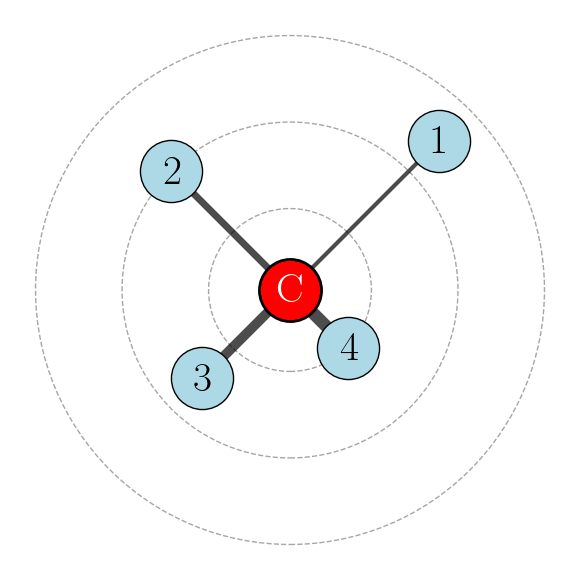

In [36]:
def crear_diagrama_con_circulos(pesos=None, radio_max=2.5, radio_min=0.8):
    if pesos is None:
        pesos = [1.0, 2.0, 3.0, 4.0]
    
    pesos_array = np.array(pesos)
    pesos_norm = pesos_array / pesos_array.max()
    distancias = radio_min + (radio_max - radio_min) * (1 - pesos_norm)
    
    angulos = [45, 135, 225, 315]
    angulos_rad = [np.radians(a) for a in angulos]
    
    pos_nodos = {'C': (0, 0)}
    for i in range(4):
        pos_nodos[f'{i+1}'] = (distancias[i] * np.cos(angulos_rad[i]), 
                               distancias[i] * np.sin(angulos_rad[i]))
    
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # Círculos de referencia
    for r in [radio_min, (radio_min+radio_max)/2, radio_max]:
        circulo = plt.Circle((0, 0), r, fill=False, linestyle='--', 
                            alpha=0.7, color='gray')
        ax.add_patch(circulo)
    
    # Aristas
    grosores = 1 + 8 * pesos_norm
    for i in range(4):
        nombre = f'{i+1}'
        x_c, y_c = pos_nodos['C']
        x_n, y_n = pos_nodos[nombre]
        ax.plot([x_c, x_n], [y_c, y_n], 'k-', 
               linewidth=grosores[i], alpha=0.7, zorder=1)
        
        x_mid = (x_c + x_n) / 2
        y_mid = (y_c + y_n) / 2
        dx = x_n - x_c
        dy = y_n - y_c
        length = np.sqrt(dx**2 + dy**2)
        if length > 0:
            offset = 0.15
            x_label = x_mid + offset * (-dy / length)
            y_label = y_mid + offset * (dx / length)
        else:
            x_label, y_label = x_mid, y_mid
        # ax.text(x_label, y_label+0, f'{pesos[i]:.1f}', 
        #        fontsize=10, ha='center', va='center',
        #        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))
    
    # Nodos
    size = 2000

    ax.scatter([0], [0], s=size, c='red', edgecolors='black', linewidth=2, zorder=2)
    ax.text(0.01, -0.02, 'C', fontsize=30, ha='center', va='center', 
           color='white', fontweight='bold')
    
    for i in range(4):
        nombre = f'{i+1}'
        x, y = pos_nodos[nombre]
        ax.scatter([x], [y], s=size, c='lightblue', edgecolors='black', 
                  linewidth=1, zorder=2)
        ax.text(x+0.02, y-0.02, nombre, fontsize=30, ha='center', va='center', 
               fontweight='bold')
    
    ax.set_aspect('equal')
    ax.axis('off')
    # ax.set_title('Distancia ∝ 1/peso (círculos de referencia)', 
                # fontsize=12, fontweight='bold')
    ax.set_xlim(-radio_max - 0.3, radio_max + 0.3)
    ax.set_ylim(-radio_max - 0.3, radio_max + 0.3)
    
    plt.tight_layout()
    return fig, ax

# Uso
pesos = [1.0, 2.0, 3.0, 4.0]
fig, ax = crear_diagrama_con_circulos(pesos, radio_max=2.5, radio_min=0.8)
fig.savefig('slides-figs/closer-nodes.pdf')
plt.show()